# Entry the market distribution - Analytics

### Import Library

In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
from utils import load_analytics_dataset, show_3_distribution_charts, show_3_sns_charts

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

### Load Price Data

In [2]:
%%time
dataset = load_analytics_dataset()

CPU times: user 1.3 s, sys: 78 ms, total: 1.38 s
Wall time: 1.48 s


In [3]:
# data = dataset[dataset.index > '2020-11-01 00:00:00'].copy()
data = dataset.copy()

In [4]:
data

,Open,High,Low,Close,Volume,hour,minute,day_of_month,month,year,...,short_mae,long_mfe,short_mfe,rr_long,rr_short,eod_return_long,eod_return_short,price_range,intraday_position,price_shape
Date,,,,,,,,,,,,,,,,,,,,,
2018-08-20 09:05:00,945.8,946.1,945.5,946.1,877,9,5,20,8,2018,...,0.570764,0.570764,0.369940,1.542857,0.648148,-0.147976,0.147976,8.9,norm,bear_grind
2018-08-20 09:10:00,945.9,946.2,945.7,945.9,604,9,10,20,8,2018,...,0.592029,0.592029,0.348874,1.696970,0.589286,-0.126863,0.126863,8.9,norm,bear_grind
2018-08-20 09:15:00,946.0,946.5,946.0,946.1,797,9,15,20,8,2018,...,0.570764,0.570764,0.369940,1.542857,0.648148,-0.147976,0.147976,8.9,norm,bear_grind
2018-08-20 09:20:00,946.0,947.1,946.0,946.8,1195,9,20,20,8,2018,...,0.496409,0.496409,0.443599,1.119048,0.893617,-0.221800,0.221800,8.9,norm,bear_grind
2018-08-20 09:25:00,946.6,947.0,946.1,946.7,915,9,25,20,8,2018,...,0.507024,0.507024,0.433083,1.170732,0.854167,-0.211260,0.211260,8.9,norm,bear_grind
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-04 14:10:00,1890.7,1891.0,1885.5,1887.3,5379,14,10,4,11,2025,...,1.080909,1.080909,0.005299,204.000000,0.004902,0.815981,-0.815981,56.7,norm,strong_bull
2025-11-04 14:15:00,1887.2,1899.0,1887.2,1898.5,13871,14,15,4,11,2025,...,0.484593,0.484593,0.079010,6.133333,0.163043,0.221227,-0.221227,56.7,norm,strong_bull
2025-11-04 14:20:00,1898.2,1907.7,1897.0,1904.2,16090,14,20,4,11,2025,...,0.168050,0.168050,0.204810,0.820513,1.218750,-0.078773,0.078773,56.7,peak,strong_bull


In [5]:
data.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'hour', 'minute',
       'day_of_month', 'month', 'year',
       ...
       'short_mae', 'long_mfe', 'short_mfe', 'rr_long', 'rr_short',
       'eod_return_long', 'eod_return_short', 'price_range',
       'intraday_position', 'price_shape'],
      dtype='str', length=113)

In [6]:
data['allow_entry'] = data['allow_entry'].fillna('NaN')

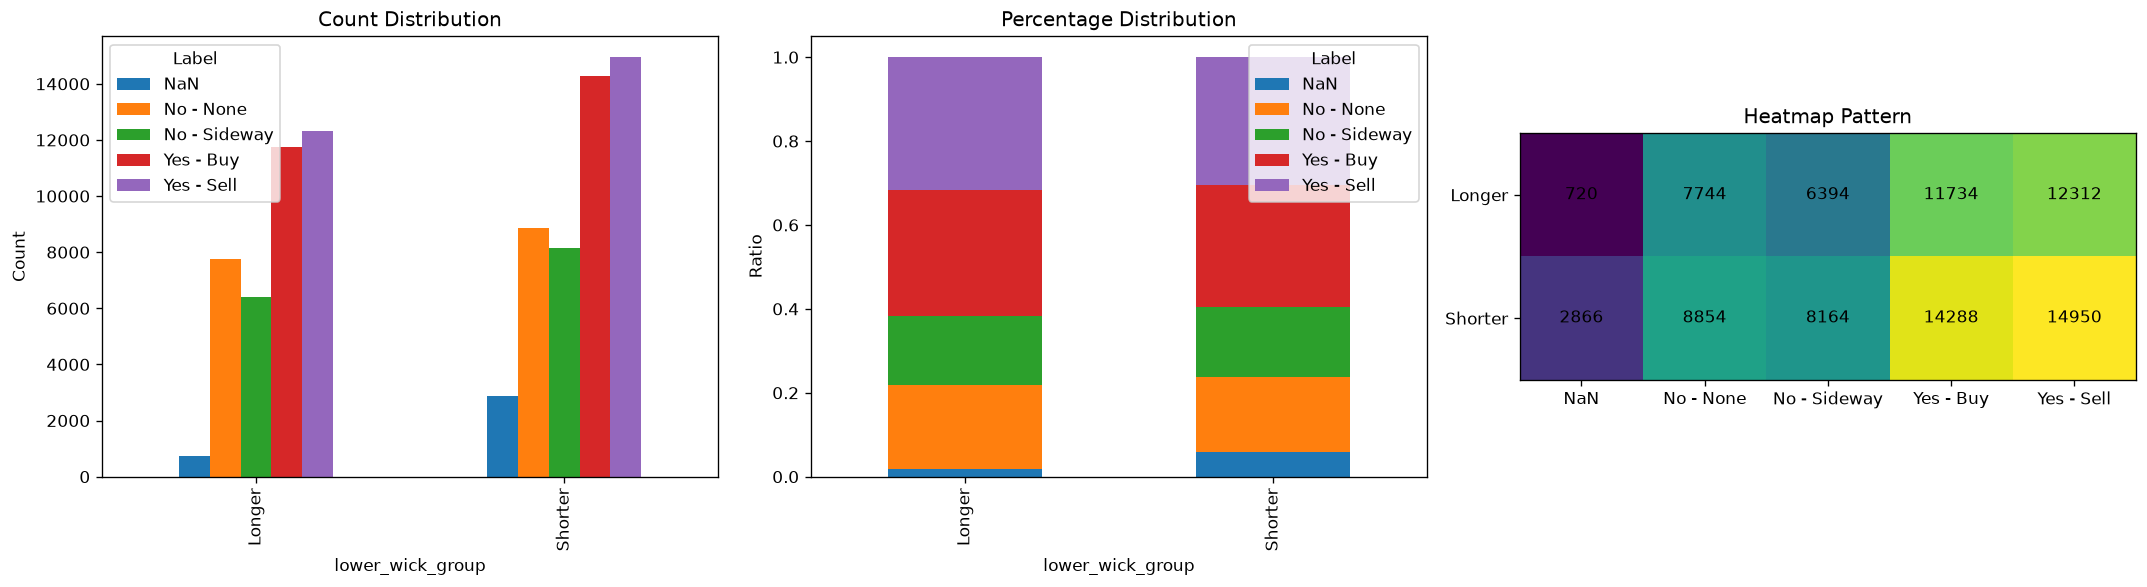

In [7]:
show_3_distribution_charts(data['lower_wick_group'], data['allow_entry'])

## Tỉ lệ % có thể vào lệnh

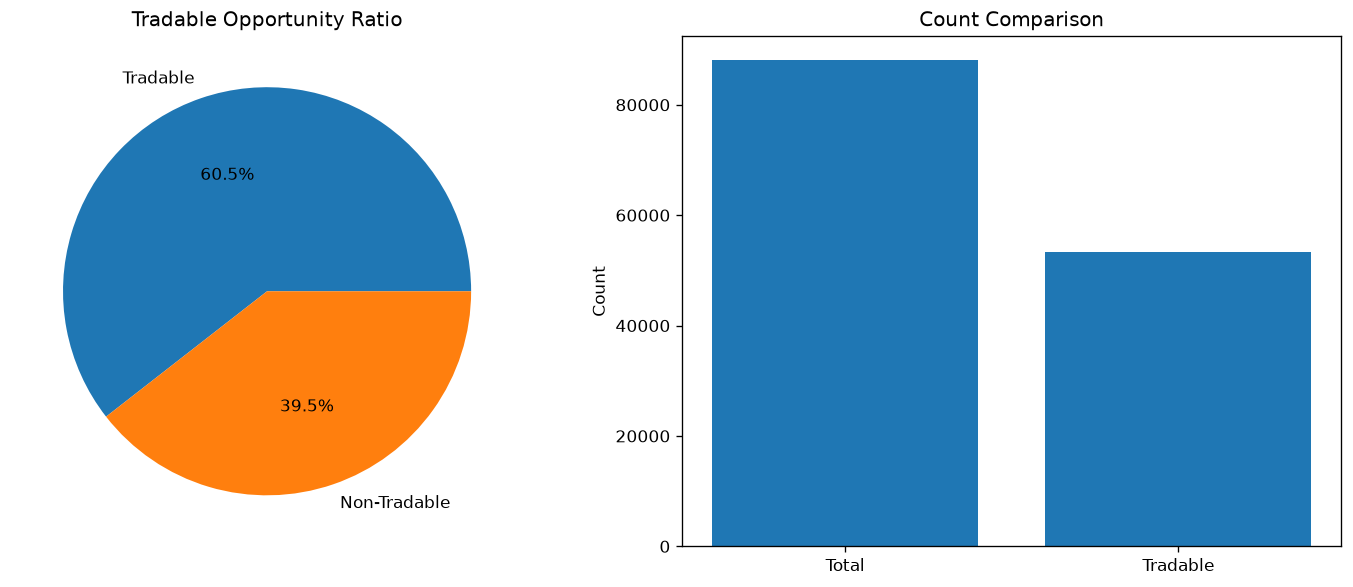

In [10]:
total_time = len(data)
tradable_time = len(data[(data.allow_entry=='Yes - Buy') | (data.allow_entry=='Yes - Sell')])
non_tradable_time = total_time - tradable_time

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Pie chart (tỷ lệ)
axes[0].pie(
    [tradable_time, non_tradable_time],
    labels=['Tradable', 'Non-Tradable'],
    autopct='%1.1f%%'
)
axes[0].set_title('Tradable Opportunity Ratio')

# 2. Bar chart (số lượng)
axes[1].bar(
    ['Total', 'Tradable'],
    [total_time, tradable_time]
)
axes[1].set_title('Count Comparison')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Analytics

In [11]:
from scipy.stats import chi2_contingency


In [12]:
ct = pd.crosstab(data['hour'], data['allow_entry'])
chi2, p, _, _ = chi2_contingency(ct)
print(p)

0.0


In [13]:
data.ema_cross_signal.unique()

<StringArray>
[nan, 'Buy', 'Sell']
Length: 3, dtype: str

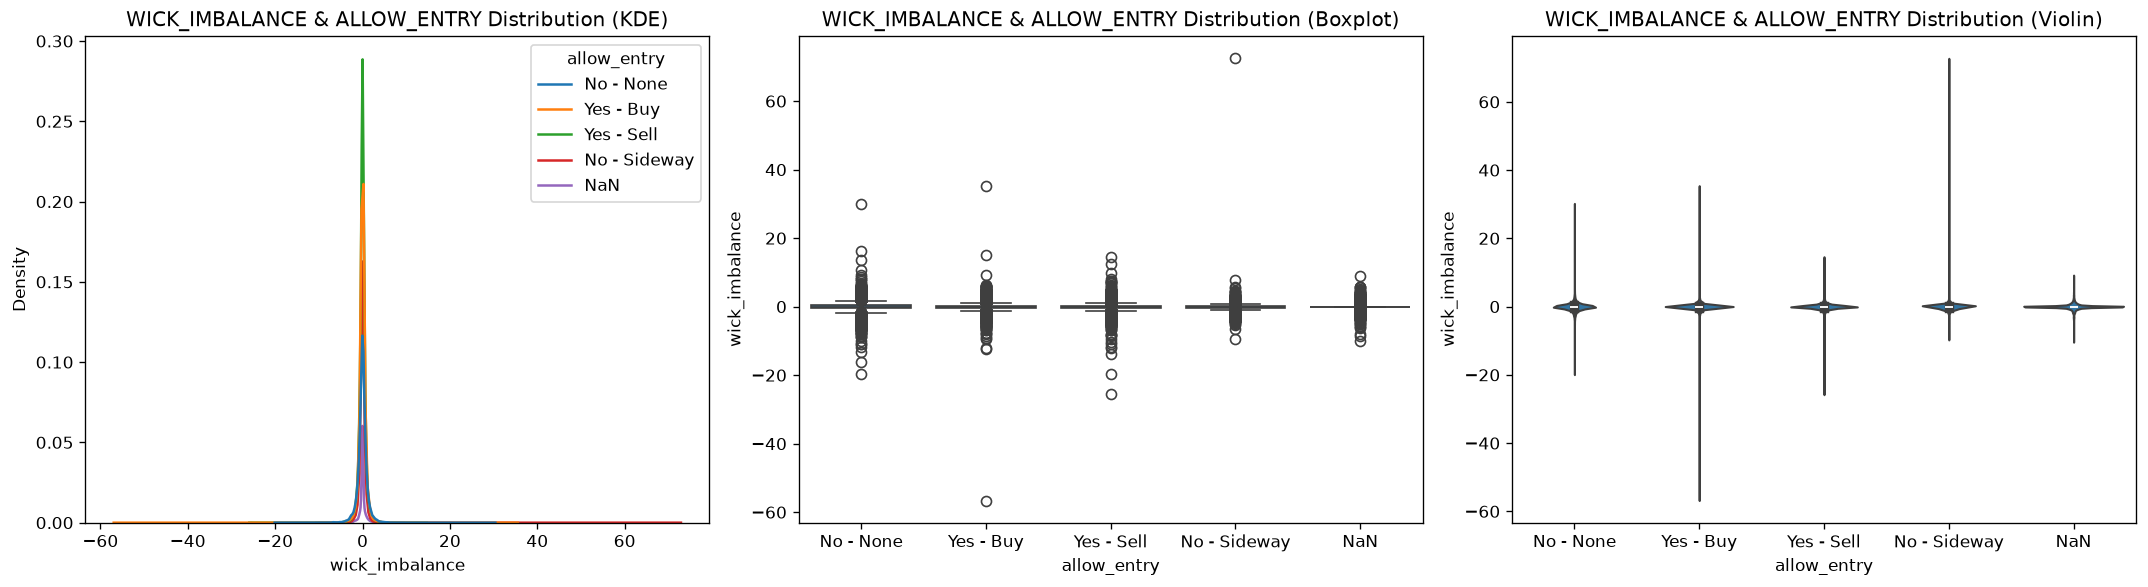

In [14]:
show_3_sns_charts(data, 'wick_imbalance', 'allow_entry')

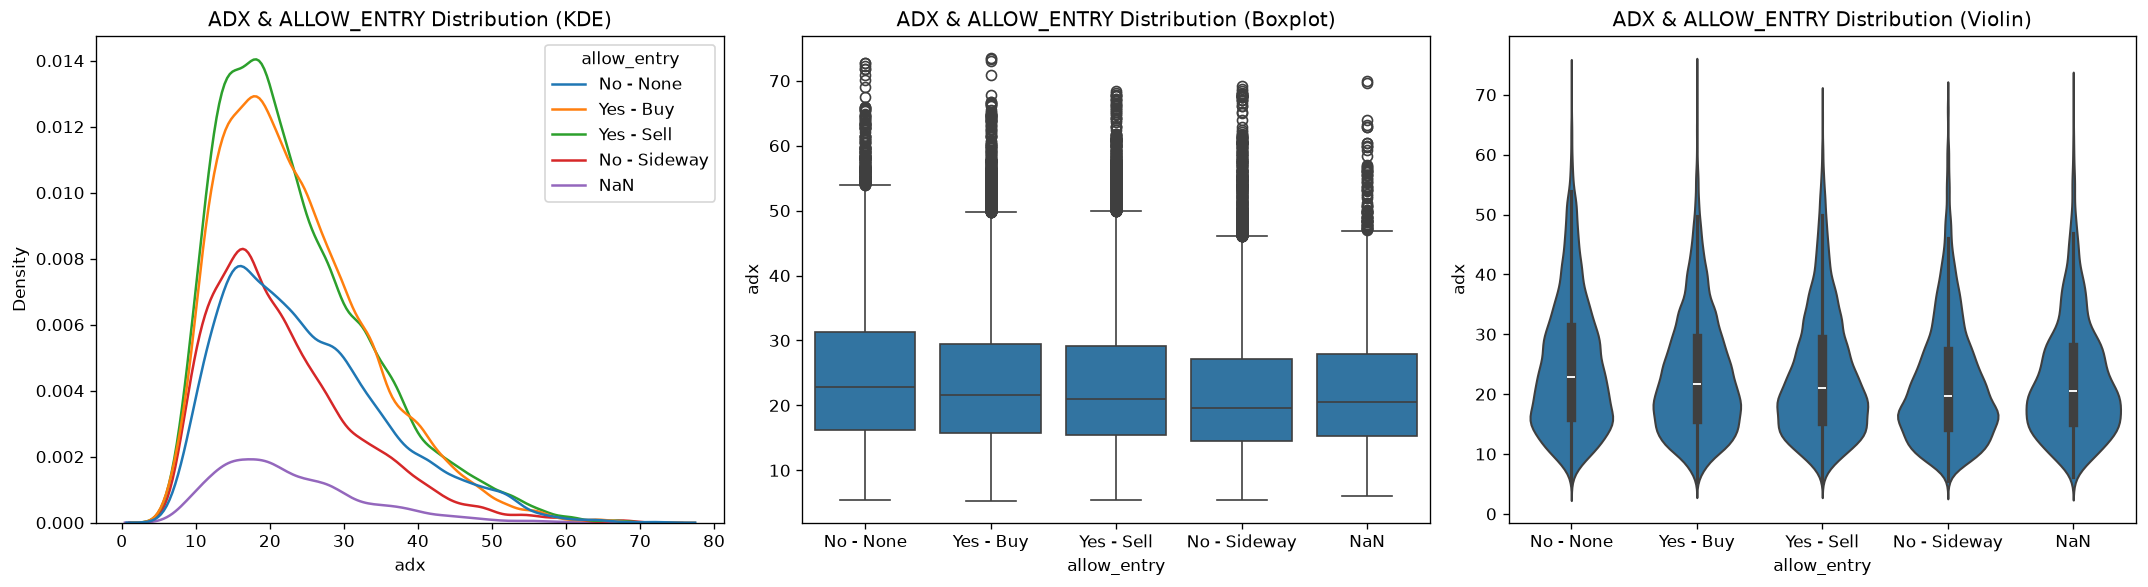

In [15]:
show_3_sns_charts(data, 'adx', 'allow_entry')

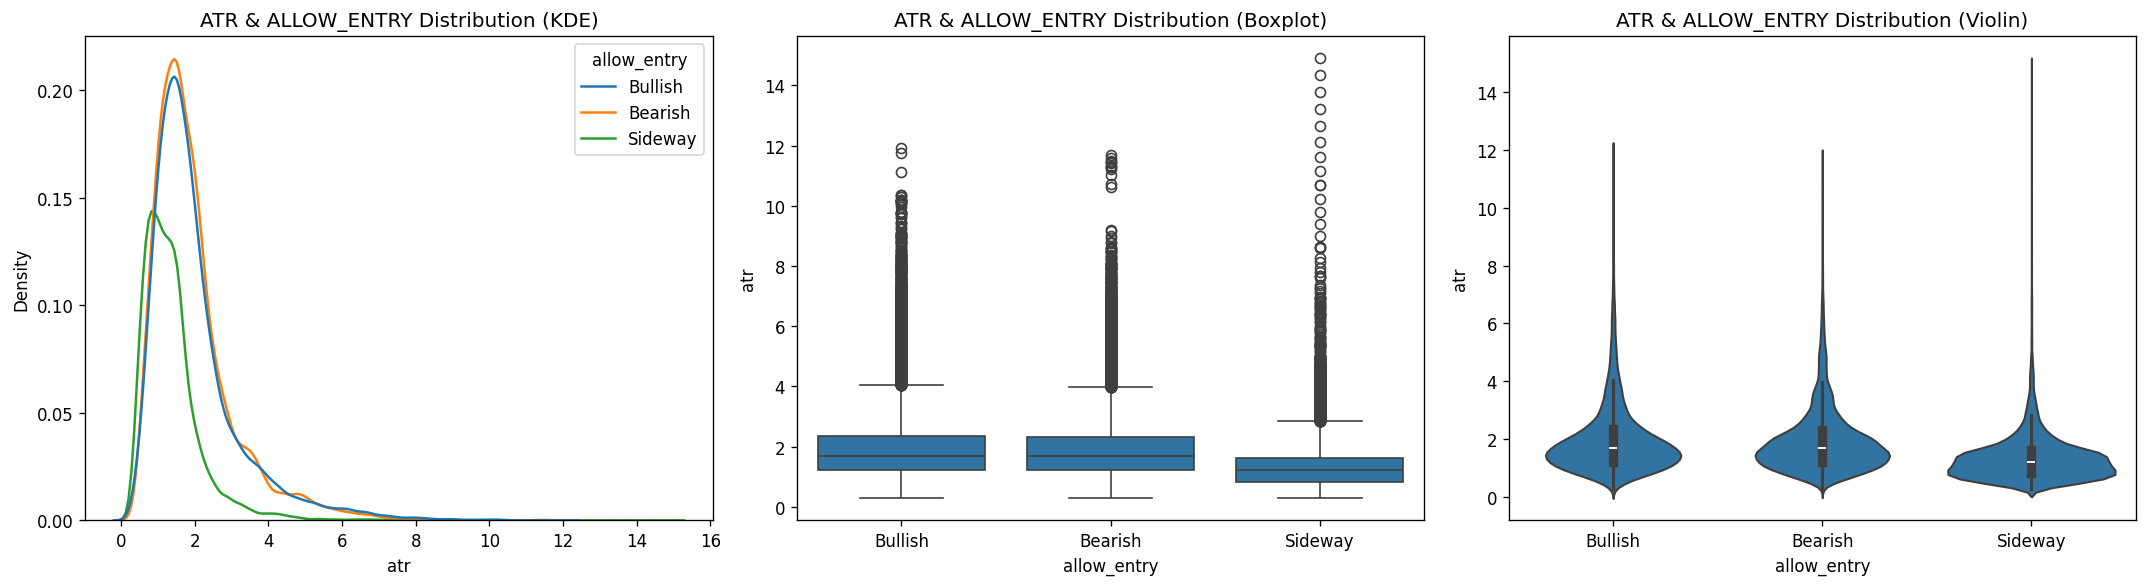

In [5]:
show_3_sns_charts(data, 'atr', 'allow_entry')

In [4]:
dfx = data[data.ema_cross_signal.notna()]

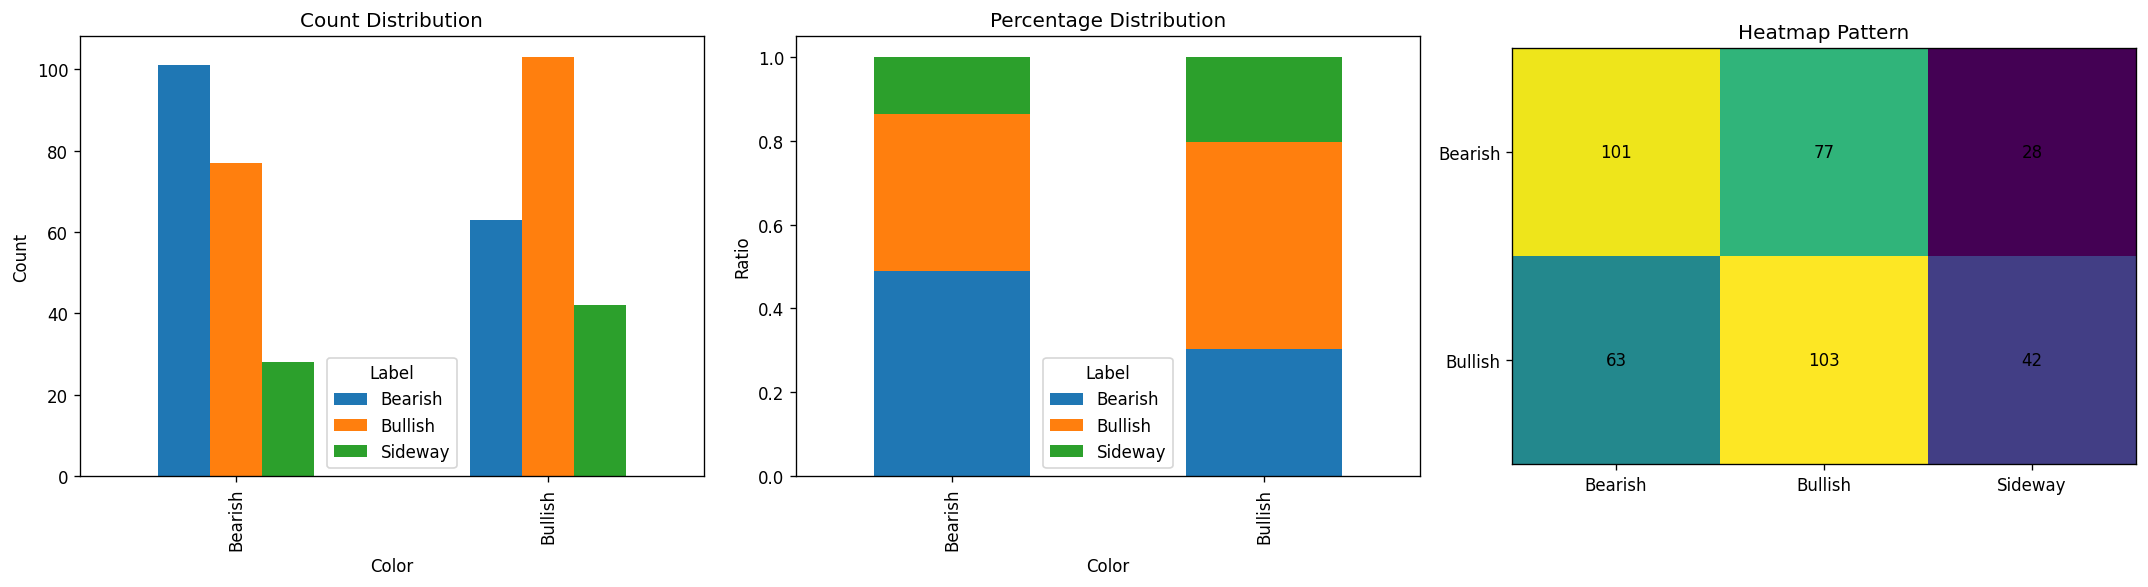

In [5]:
show_3_distribution_chart(dfx['ema_cross_signal'], dfx['allow_entry'])

### 3. MQH giữa màu sắc nến và Allow Entry

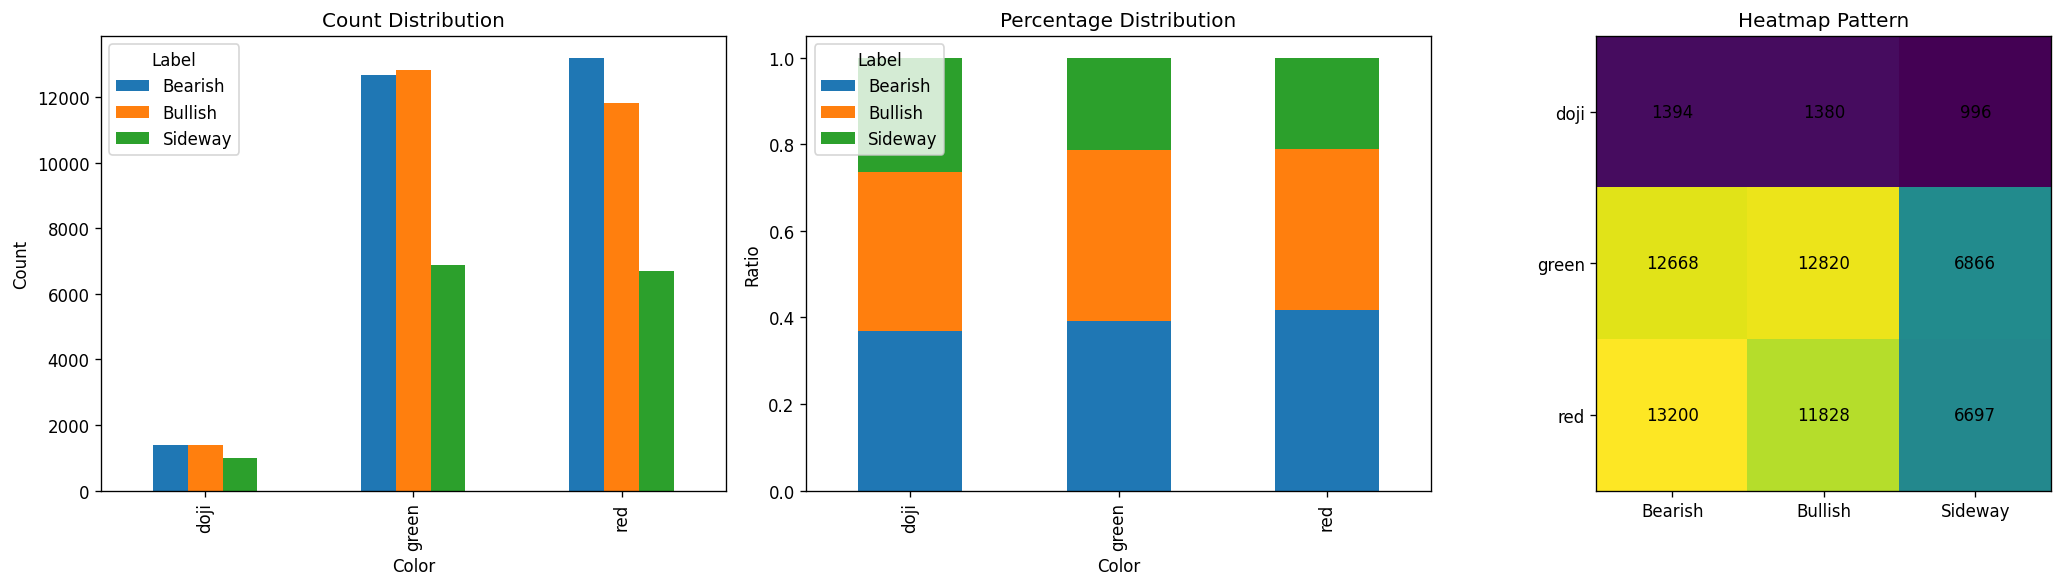

In [6]:
show_3_distribution_chart(data['color'], data['allow_entry'])

## 2. MQH giữa RSI và Allow Entry

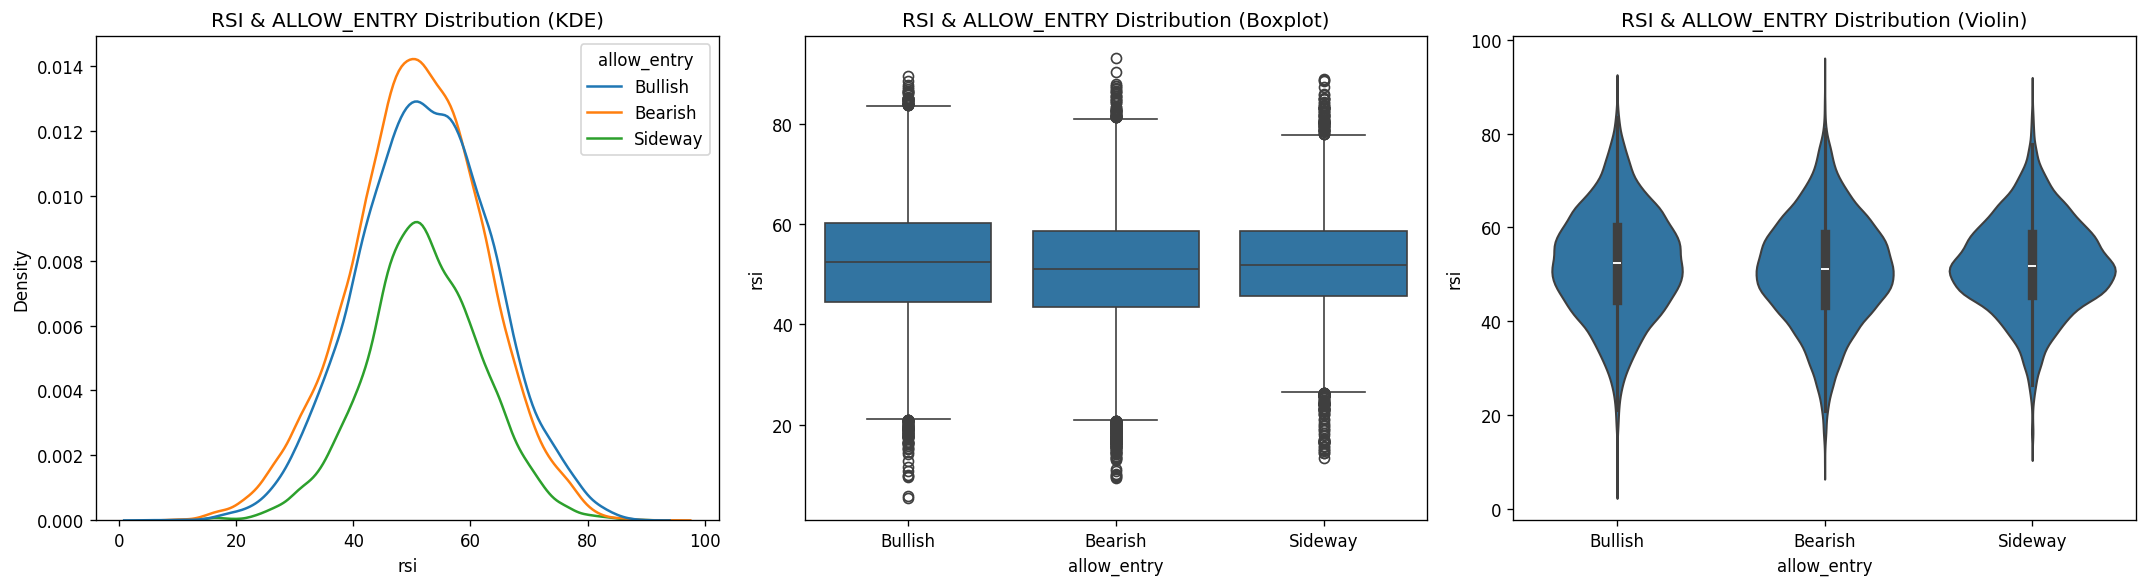

In [4]:
show_3_sns_charts(data, 'rsi', 'allow_entry')

## 1. MQH giữa Hour và Allow Entry

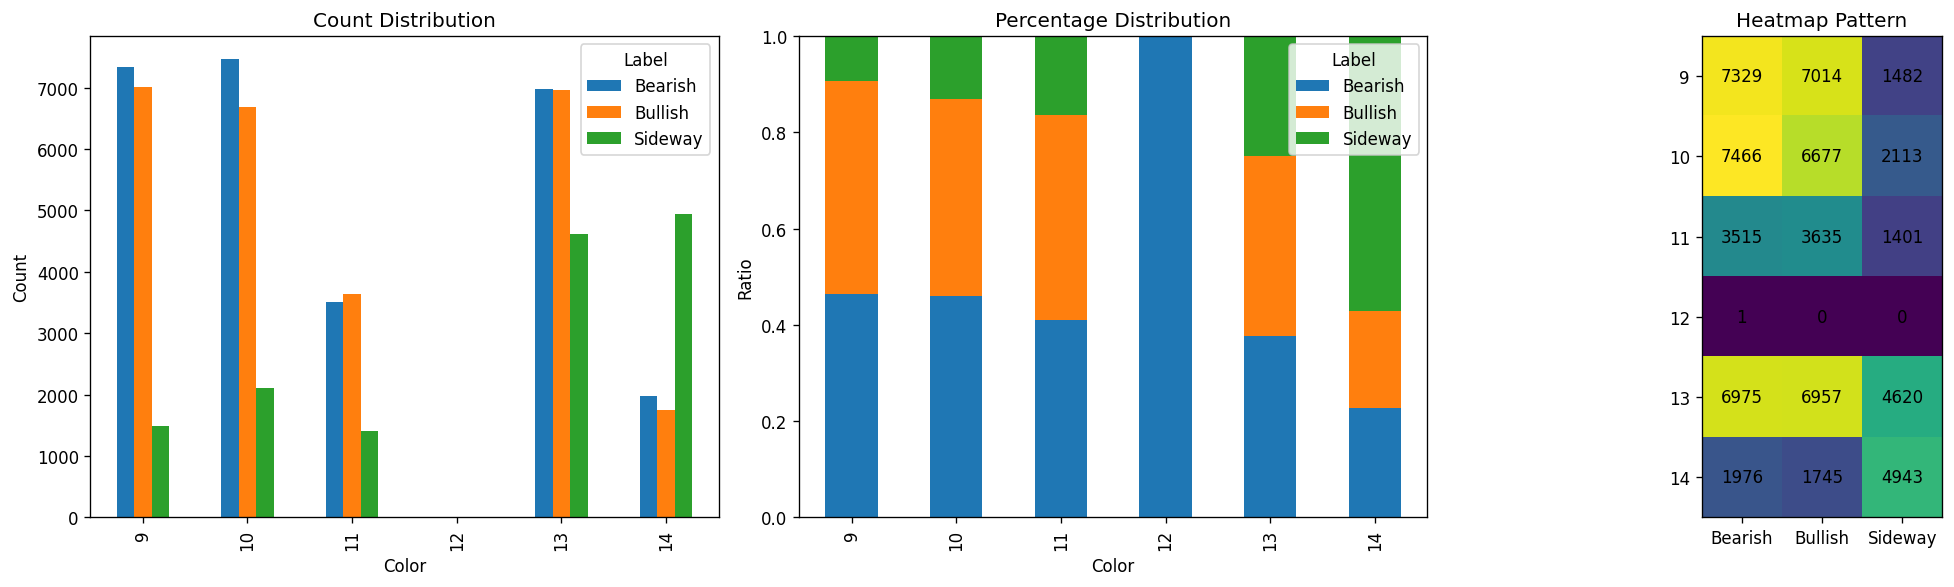

In [9]:
show_3_distribution_chart(data['hour'], data['allow_entry'])